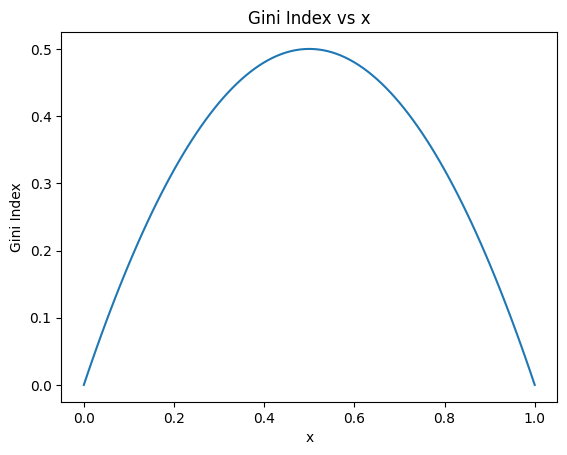

C:\Users\Owen Hirsch\AppData\Local\Temp\ipykernel_15756\158099353.py:32: RuntimeWarning: divide by zero encountered in log2
  entropy = -X * np.log2(X) - x2 * np.log2(x2)
C:\Users\Owen Hirsch\AppData\Local\Temp\ipykernel_15756\158099353.py:32: RuntimeWarning: invalid value encountered in multiply
  entropy = -X * np.log2(X) - x2 * np.log2(x2)


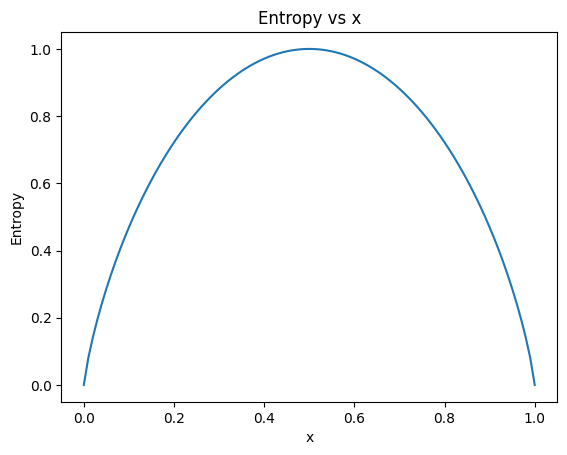

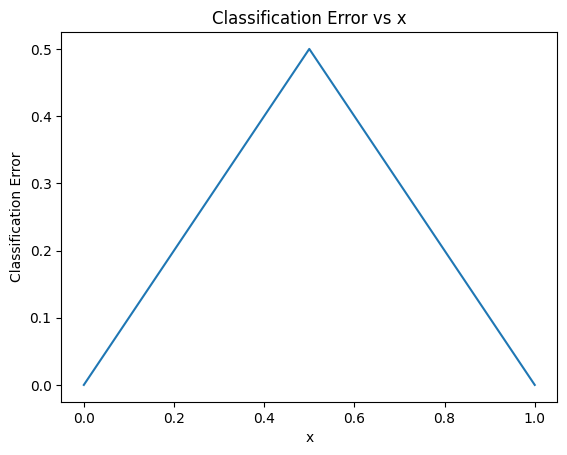

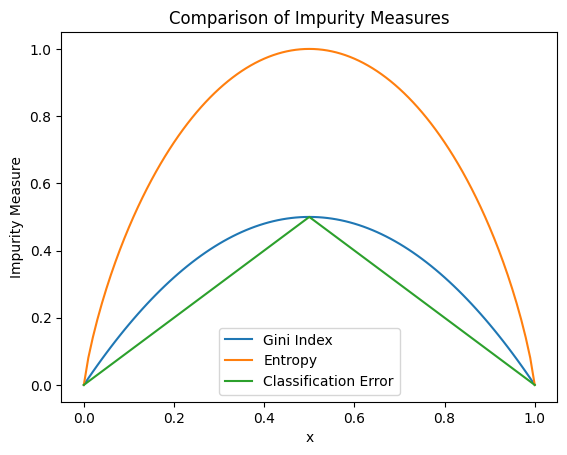

In [19]:
## Q 3


import numpy as np
import pandas as pd

# X ranges from 0 to 1 in steps of 0.01
X = np.arange(0.0, 1.0 + 0.01, 0.01)

# x2 is 1 - X
x2 = 1.0 - X

# quick check (optional) - make a dataframe with columns x and x2
df = pd.DataFrame({'x': X, 'x2': x2})
df.head()

gini = X*(1-X) + x2*(1-x2)

# add gini to dataframe
df['gini'] = gini

# display updated dataframe head
df.head()

import matplotlib.pyplot as plt
plt.plot(X, gini)
plt.xlabel('x')
plt.ylabel('Gini Index')
plt.title('Gini Index vs x')
plt.show()

entropy = -X * np.log2(X) - x2 * np.log2(x2)
# handle the case when X=0 to avoid NaN
entropy = np.nan_to_num(entropy)
# add entropy to dataframe
df['entropy'] = entropy
plt.plot(X, entropy)
plt.xlabel('x')     
plt.ylabel('Entropy')
plt.title('Entropy vs x')
plt.show()

### classification error
classification_error = 1 - np.maximum(X, x2)
# add classification error to dataframe
df['classification_error'] = classification_error
plt.plot(X, classification_error)
plt.xlabel('x')
plt.ylabel('Classification Error')
plt.title('Classification Error vs x')
plt.show()


plt.plot(X, gini, label='Gini Index')
plt.plot(X, entropy, label='Entropy')   
plt.plot(X, classification_error, label='Classification Error')
plt.xlabel('x')
plt.ylabel('Impurity Measure')
plt.title('Comparison of Impurity Measures')
plt.legend()
plt.show()

Question 2:

Boosting becomes an additive model when using depth-one trees (stumps), because each tree can only split on a single variable. The first tree fits the relationship between one variable (X_1) and the target( Y.) The residuals from this fit represent the portion of (Y) not explained by (X_1). The next tree then fits another variable ( X_2) to these residuals, capturing the next layer of structure. This process continues, with each tree modeling what remains unexplained by the previous trees, using only one variable at a time. Since each function added to the model is univariate and non-interactive, the overall structure is additive. Depending on the predictors used, the model is essentially the same as choosing a regression with those same predictors added up.

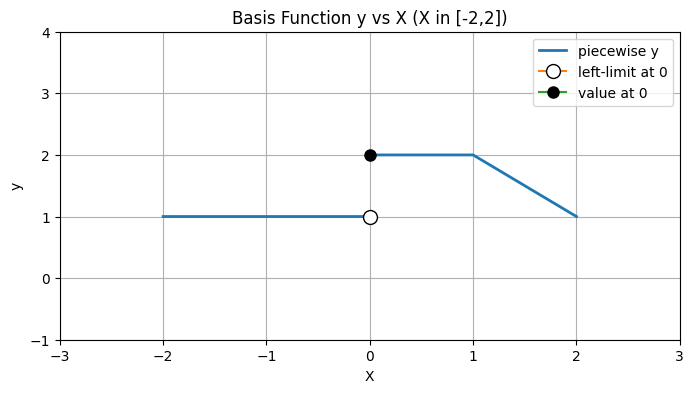

   x    y              slope_left slope_right
0 -2  1.0  NA (Technically y = 1)       y = 1
1 -1  1.0                   y = 1       y = 1
2  0  2.0                   y = 1       y = 2
3  1  2.0                   y = 2   y = 3 - x
4  2  1.0               y = 3 - x          NA


In [20]:
### Question 1
# Use a continuous X defined from -3 to 3 and evaluate the piecewise function on that domain
import numpy as np
import matplotlib.pyplot as plt

# continuous X from -3 to 3 (inclusive)
X = np.linspace(-3.0, 3.0, 601)

# Vectorized piecewise definition for array X
# y = 1 for -2 <= X < 0
# y = 2 for 0 <= X < 1
# y = 3 - X for 1 <= X <= 2
# elsewhere: NaN

y = np.where((X >= -2) & (X < 0),
             1,
             np.where((X > 0) & (X < 1),
                      2,
                      np.where((X >= 1) & (X <= 2),
                               3 - X,
                               np.nan)))
# show a few values to verify

# graph x vs y
plt.figure(figsize=(8,4))
plt.plot(X, y, lw=2, label='piecewise y')

# Add open circle at X=0, y=1 (left-limit) and closed circle at X=0, y=2 (value at 0)
plt.plot(0, 1, marker='o', markersize=10, markeredgecolor='k', markerfacecolor='white', label='left-limit at 0')
plt.plot(0, 2, marker='o', markersize=8, markeredgecolor='k', markerfacecolor='k', label='value at 0')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Basis Function y vs X (X in [-2,2])')
plt.ylim(-1, 4)
plt.xlim(-3, 3)
plt.grid(True)
plt.legend()
plt.show()



### table

# Create a table for specific X values and compute the corresponding y values
# and the left/right slopes at those points.

points = [-2, -1, 0, 1, 2]

def piecewise_value(x):
    # definition:
    # y = 1      for -2 <= x < 0
    # y = 2      for 0 <= x < 1
    # y = 3 - x  for 1 <= x <= 2
    if -2 <= x < 0:
        return 1.0
    elif 0 <= x < 1:
        return 2.0
    elif 1 <= x <= 2:
        return 3.0 - x
    else:
        return np.nan

def slopes_at_point(x):
    # return (left_slope, right_slope)
    # slopes inside intervals:
    # (-2,0): slope 0 ; (0,1): slope 0 ; (1,2): slope -1
    if x == -2:
        return ("NA (Technically y = 1)", "y = 1")
    if -2 < x < 0:
        return ("y = 1", "y = 1")
    if x == 0:
        return ("y = 1", "y = 2")   # both left and right slopes are 0 (constant on both sides)
    if 0 < x < 1:
        return ("y = 2", "y = 2")
    if x == 1:
        return ("y = 2", "y = 3 - x")  # left slope 0, right slope -1 (kink at x=1)
    if 1 < x < 2:
        return ("y = 3 - x", "y = 3 - x")
    if x == 2:
        return ("y = 3 - x", "NA")
    return (np.nan, np.nan)

rows = []
for xp in points:
    yv = piecewise_value(xp)
    ls, rs = slopes_at_point(xp)
    rows.append({'x': xp, 'y': yv, 'slope_left': ls, 'slope_right': rs})

table = pd.DataFrame(rows)
print(table)

####( from 2 - 3 technically y = 1 based on the function definition in the textbook)